# Case study 3 — Causal analysis of the London ULEZ with Synthetic Control

Reproduces the paper's ULEZ case study (Sect. *Causal example: ULEZ*): the
London Ultra Low Emission Zone launched on 2019-04-08. The bundled `scm`
panel contains monthly **deweathered** NO2 for 104 UK monitoring sites
(2016–2021); deweathering first removes meteorological variability so that
the SCM comparison is between emission-driven signals.

Design (the paper's *primary* window): pre-period 2017-01 to 2019-03, post
period through 2020-02 — stopping **before COVID** so the estimated effect
is attributable to the ULEZ. The treated unit is the kerbside site MY1;
donors are traffic-type sites elsewhere with complete coverage.

In [1]:
import os

# Cap library threads BEFORE importing normet/lightgbm — on shared machines
# (HPC login nodes, CI runners) unbounded OpenMP threads can oversubscribe
# the node and appear to hang.
os.environ.setdefault("OMP_NUM_THREADS", "4")

import matplotlib.pyplot as plt
import normet as nm

scm_panel = nm.datasets.load_scm()

TREATED = "MY1"
CUTOFF = "2019-04-01"

df = scm_panel.query("'2017-01-01' <= date < '2020-03-01'")
df = df[df["type"].str.contains("Traffic")]
counts = df.dropna(subset=["NO2_dw"]).groupby("code").size()
donors = [c for c in counts[counts == df["date"].nunique()].index if c != TREATED]
df = df[df["code"].isin(donors + [TREATED])]
print(f"{len(donors)} donor sites, {df['date'].nunique()} months")

53 donor sites, 38 months


## 1. Augmented (ridge) SCM

In [2]:
res = nm.run_scm(
    df=df, date_col="date", outcome_col="NO2_dw", unit_col="code",
    treated_unit=TREATED, donors=donors, cutoff_date=CUTOFF,
    scm_backend="scm",
)
att_post = res.loc[res.index >= CUTOFF, "effect"].mean()
print(f"ATT (post-period mean effect): {att_post:.2f} µg/m3")
res.tail()

ATT (post-period mean effect): -18.14 µg/m3


,observed,synthetic,effect
date,,,
2019-10-31,59.039118,81.231028,-22.191910
2019-11-30,58.218322,76.929542,-18.711220
2019-12-31,55.795105,71.409851,-15.614746
2020-01-31,56.920649,76.724070,-19.803421
2020-02-29,61.501946,80.159918,-18.657972


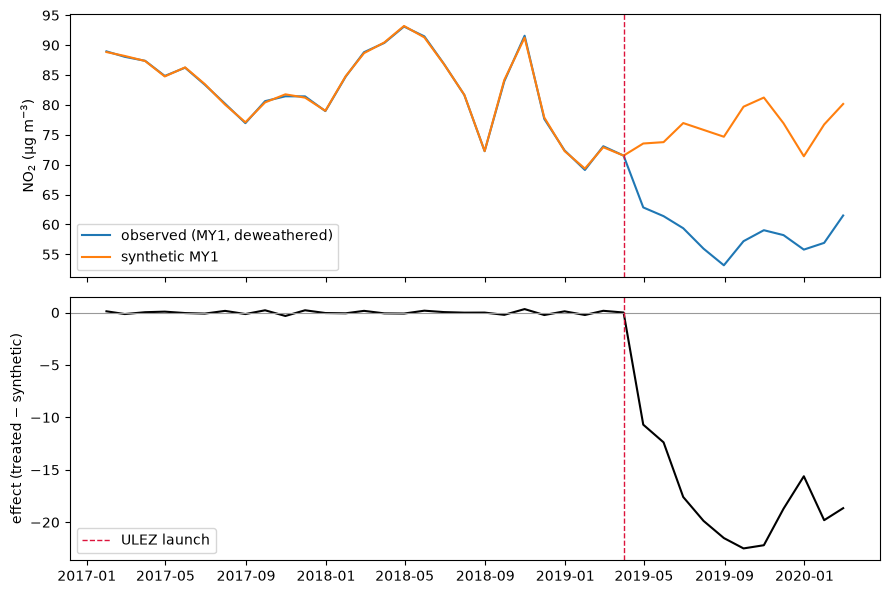

In [3]:
fig, axes = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axes[0].plot(res.index, res["observed"], label="observed (MY1, deweathered)")
axes[0].plot(res.index, res["synthetic"], label="synthetic MY1")
axes[0].axvline(x=__import__("pandas").Timestamp(CUTOFF), color="crimson", ls="--", lw=1)
axes[0].set_ylabel("NO$_2$ (µg m$^{-3}$)")
axes[0].legend()
axes[1].plot(res.index, res["effect"], color="k")
axes[1].axhline(0, color="0.6", lw=0.8)
axes[1].axvline(x=__import__("pandas").Timestamp(CUTOFF), color="crimson", ls="--", lw=1,
                label="ULEZ launch")
axes[1].set_ylabel("effect (treated − synthetic)")
axes[1].legend()
plt.tight_layout()

## 2. Robustness: SCM variants

`nm.run_scm` dispatches to the whole family via `scm_backend` (augmented
ridge, Abadie simplex, DiD, matrix completion) on the same design.

In [4]:
import pandas as pd

METHODS = {
    "scm": "augmented (ridge)",
    "abadie": "Abadie simplex",
    "did": "difference-in-differences",
    "mcnnm": "matrix completion",
}

att = {}
for backend, label in METHODS.items():
    r = nm.run_scm(
        df=df, date_col="date", outcome_col="NO2_dw", unit_col="code",
        treated_unit=TREATED, donors=donors, cutoff_date=CUTOFF,
        scm_backend=backend,
    )
    att[label] = r.loc[r.index >= CUTOFF, "effect"].mean()

pd.Series(att, name="post-period ATT (µg/m3)").round(2)

augmented (ridge)           -18.14
Abadie simplex               -6.83
difference-in-differences   -20.67
matrix completion           -21.68
Name: post-period ATT (µg/m3), dtype: float64

## 3. Significance: placebo-in-space

Each donor is treated as a placebo unit; the spread of placebo effects gives
a 95% band for the null of no effect.

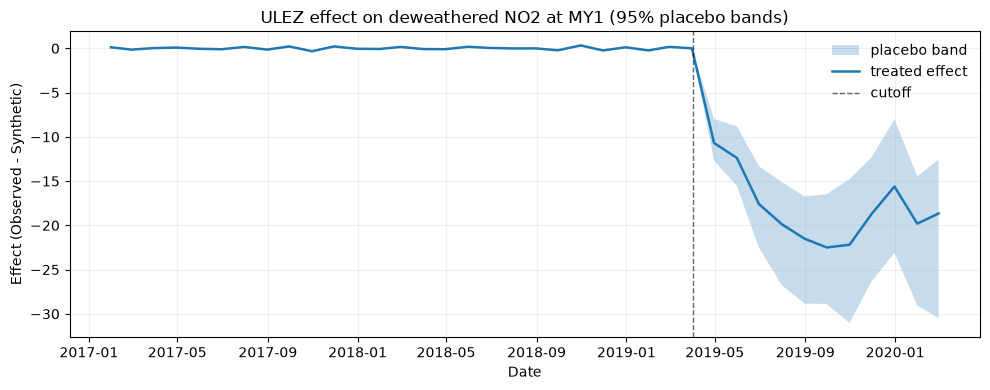

In [5]:
placebo = nm.placebo_in_space(
    df, date_col="date", outcome_col="NO2_dw", unit_col="code",
    treated_unit=TREATED, donors=donors, cutoff_date=CUTOFF, scm_backend="scm",
)
bands = nm.effect_bands_space(placebo, level=0.95, method="quantile")
nm.plot_effect_with_bands(bands, cutoff_date=CUTOFF,
                          title="ULEZ effect on deweathered NO2 at MY1 (95% placebo bands)")
plt.tight_layout()